# Dow Jones Daily Processing (US Market Hours)
This notebook:
1. Converts timestamps from **Europe/Madrid** to **America/New_York**.
2. Reassigns observations **outside 09:30–16:30 ET** (and weekends/holidays) to the **next US trading day**.
3. Aggregates to **daily mean**.
4. Imputes **missing values** (LOCF + backfill for initial gaps).
5. **Detects and adjusts stock splits** (back-adjustment on prices; inverse on volumes).
6. Reads your CSV from `/mnt/data/AAPL_marketstack.csv` and writes the result to `/mnt/data/AAPL_daily_processed.csv`.

> If you have `pandas_market_calendars` installed, holidays will be handled automatically (XNYS). If not, you can provide a list of US holidays manually.


In [39]:
# Imports
import pandas as pd
import numpy as np
from datetime import time, timedelta
import re

# Optional (only if you want automatic US market holidays via XNYS):
# !pip install pandas-market-calendars


In [40]:
# Calendar utilities (NYSE)
def get_nyse_sessions(start_date, end_date, holidays=None):
    """Return NYSE trading sessions between start_date and end_date.
    - Tries pandas_market_calendars (XNYS).
    - If unavailable, uses weekdays (Mon-Fri) minus provided holidays.
    """
    try:
        import pandas_market_calendars as mcal
        nyse = mcal.get_calendar('XNYS')
        sched = nyse.schedule(start_date=start_date, end_date=end_date)
        return pd.DatetimeIndex(sched.index.tz_localize(None))
    except Exception:
        bdays = pd.bdate_range(start=start_date, end=end_date, freq='C')  # Mon-Fri
        if holidays:
            hol = pd.to_datetime(holidays).normalize()
            bdays = bdays.difference(hol)
        return bdays

def build_next_trading_day_map(sessions):
    sess = pd.DatetimeIndex(sessions.normalize().unique()).sort_values()
    sess_set = set(sess.date)
    next_map = {}
    for d in sess:
        next_map[d.date()] = d.date()
    return sess, sess_set, next_map

def next_trading_day(date_like, sessions, sess_set, next_map):
    d = date_like
    if d in next_map:
        return next_map[d]
    idx = sessions.searchsorted(pd.Timestamp(d))
    if idx < len(sessions):
        nd = sessions[idx].date()
    else:
        nd = sessions[-1].date()
    next_map[d] = nd
    return nd

def map_to_trading_day_nyse(dt_newyork, sessions, sess_set, next_map,
                            market_open=time(9,30), market_close=time(16,30)):
    """Map timestamp to a US trading date.
    - If within 09:30–16:30 ET and a trading day, keep same date.
    - Otherwise (out-of-hours or non-trading day), roll to the next trading day.
    """
    d = dt_newyork.date()
    t = dt_newyork.time()
    in_hours = (t >= market_open) and (t <= market_close)
    if (d in sess_set) and in_hours:
        return d
    d_plus = d + timedelta(days=1)
    return next_trading_day(d_plus, sessions, sess_set, next_map)


In [41]:
# CSV parsing & column detection
def guess_timestamp_column(df):
    candidates = ['timestamp', 'time', 'date', 'datetime']
    for c in df.columns:
        lc = c.lower()
        if lc in candidates or re.search(r'(time|date)', lc):
            try:
                pd.to_datetime(df[c])
                return c
            except Exception:
                pass
    for c in df.columns:
        try:
            pd.to_datetime(df[c])
            return c
        except Exception:
            pass
    raise ValueError("No parseable datetime column found.")

def detect_price_volume_columns(df_cols):
    price_keywords = ['open','high','low','close','last','price','adj_close','adjusted_close','bid','ask','mid']
    vol_keywords = ['volume','vol','shares']
    price_candidates, vol_candidates = [], []
    for c in df_cols:
        lc = c.lower()
        if any(k == lc or f'_{k}' in lc or lc.endswith(k) for k in price_keywords):
            price_candidates.append(c)
        if any(k == lc or f'_{k}' in lc or lc.endswith(k) for k in vol_keywords):
            vol_candidates.append(c)
    return price_candidates, vol_candidates


In [42]:
# Aggregation to daily (mean) + LOCF imputations
def aggregate_daily_mean_with_roll(df, ts_col, tz_from='Europe/Madrid', holidays=None):
    # Parse & timezone to ET
    ts = pd.to_datetime(df[ts_col], errors='coerce')
    if ts.dt.tz is None:
        ts = ts.dt.tz_localize(tz_from)
    else:
        ts = ts.dt.tz_convert(tz_from)
    ts_et = ts.dt.tz_convert('America/New_York')

    # Build trading sessions
    start_date = ts_et.min().date() - timedelta(days=5)
    end_date   = ts_et.max().date() + timedelta(days=10)
    sessions = get_nyse_sessions(start_date, end_date, holidays=holidays)
    sessions, sess_set, next_map = build_next_trading_day_map(sessions)

    # Map each timestamp to a trading date
    trading_dates = ts_et.map(lambda x: map_to_trading_day_nyse(x, sessions, sess_set, next_map))

    df2 = df.copy()
    df2['_trading_date'] = pd.to_datetime(trading_dates)

    # Aggregate numeric columns by daily mean
    num_cols = df2.select_dtypes(include=[np.number]).columns.tolist()
    daily = df2.groupby('_trading_date')[num_cols].mean().sort_index()

    # LOCF + backfill for initial gaps
    daily = daily.ffill().bfill()
    return daily


In [43]:
# Split detection & adjustment
def detect_splits(daily_prices, candidate_factors=(2,3,4,5,10), tol=0.03):
    if 'close' in daily_prices.columns:
        close = daily_prices['close']
    elif 'adj_close' in daily_prices.columns:
        close = daily_prices['adj_close']
    else:
        close = daily_prices.select_dtypes(include=[np.number]).iloc[:,0]
    r = close / close.shift(1)
    split_factor_series = pd.Series(1.0, index=close.index)
    for f in candidate_factors:
        down = (r - (1.0 / f)).abs() <= tol
        up   = (r - f).abs() <= tol  # reverse-split (optional usage)
        split_factor_series[down] = f
    return split_factor_series

def apply_split_adjustment(daily_df, split_factors, price_cols, volume_cols):
    adj = pd.Series(1.0, index=daily_df.index)
    for dt, f in split_factors.items():
        if f != 1 and not pd.isna(f):
            adj.loc[:dt - pd.Timedelta(days=1)] *= f

    adjusted = daily_df.copy()
    for c in price_cols:
        if c in adjusted.columns:
            adjusted[c] = adjusted[c] * adj
    for c in volume_cols:
        if c in adjusted.columns:
            adjusted[c] = adjusted[c] / adj.replace(0, np.nan)
    return adjusted


In [44]:
# Orchestrator
def process_dowjones_csv(
    csv_path,
    tz_from='Europe/Madrid',
    timestamp_col=None,
    holidays=None,              # list like ['2025-01-01', ...] if you don't use pandas_market_calendars
    output_path=None,
    imputation='locf',
    adjust_splits=True
):
    df = pd.read_csv(csv_path)
    if timestamp_col is None:
        timestamp_col = guess_timestamp_column(df)

    price_cols, volume_cols = detect_price_volume_columns(df.columns)

    daily = aggregate_daily_mean_with_roll(
        df, timestamp_col, tz_from=tz_from, holidays=holidays
    )

    if imputation == 'locf':
        daily = daily.ffill().bfill()
    elif imputation == 'none':
        pass
    else:
        daily = daily.interpolate(limit_direction='both')

    if adjust_splits and len(price_cols) > 0:
        # Ensure we have a 'close' proxy if not present
        if 'close' not in daily.columns:
            common_price_cols = [c for c in ['close','adj_close','last','price','open','high','low'] if c in daily.columns]
            if len(common_price_cols) == 0:
                mapped = [c for c in price_cols if c in daily.columns]
                if len(mapped) == 0:
                    common_price_cols = [daily.select_dtypes(include=[np.number]).columns[0]]
                else:
                    common_price_cols = mapped
            daily['close'] = daily[common_price_cols].mean(axis=1)

        splits = detect_splits(daily[['close']].copy())
        split_events = splits[splits != 1].astype(float)
        split_dict = dict(zip(split_events.index, split_events.values))

        price_cols_in = [c for c in daily.columns if c.lower() in [pc.lower() for pc in price_cols] or c.lower() in ['open','high','low','close','adj_close','price','last']]
        volume_cols_in = [c for c in daily.columns if c.lower() in [vc.lower() for vc in volume_cols] or c.lower() in ['volume','vol','shares']]

        daily = apply_split_adjustment(daily, split_dict, price_cols_in, volume_cols_in)

    daily.index.name = 'date'
    if output_path:
        daily.to_csv(output_path, index=True)
    return daily


In [45]:
import caas_jupyter_tools

ModuleNotFoundError: No module named 'caas_jupyter_tools'

## Run the pipeline on your CSV
This cell reads `/mnt/data/AAPL_marketstack.csv`, processes it, shows a preview, and saves the result to `/mnt/data/AAPL_daily_processed.csv`.  
If you do not have `pandas_market_calendars` installed, you can list US holidays in `us_holidays_example`.


In [ ]:
# Example: process your uploaded CSV (safe display without external tools)
csv_path = "C:/Users/benat\Desktop/RETO/RETO_9/DowJones/AAPL_marketstack.csv"  # <-- your file (already uploaded)
output_path = "AAPL_daily_processed.csv"

# Optional manual holidays if you don't have pandas_market_calendars (leave empty otherwise)
us_holidays_example = [
    # "2025-01-01", "2025-01-20", "2025-02-17", "2025-04-18", "2025-05-26",
    # "2025-06-19", "2025-07-04", "2025-09-01", "2025-11-27", "2025-12-25"
]

daily_df = process_dowjones_csv(
    csv_path=csv_path,
    tz_from="Europe/Madrid",
    holidays=us_holidays_example,
    output_path=output_path,
    imputation="locf",
    adjust_splits=True
)

# Try nice display if available, otherwise print
try:
    from caas_jupyter_tools import display_dataframe_to_user
    display_dataframe_to_user("Processed daily (preview)", daily_df.head(20))
except Exception as e:
    print("Preview (first 20 rows):")
    try:
        from IPython.display import display
        display(daily_df.head(20))
    except Exception:
        print(daily_df.head(20).to_string())

print(f"Saved processed CSV to: {output_path}")


<>:2: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\D'
C:\Users\benat\AppData\Local\Temp\ipykernel_6696\428956105.py:2: SyntaxWarning: invalid escape sequence '\D'
  csv_path = "C:/Users/benat\Desktop/RETO/RETO_9/DowJones/AAPL_marketstack.csv"  # <-- your file (already uploaded)


Preview (first 20 rows):


,open,high,low,last,close,volume
date,,,,,,
2018-06-06,578.910000,579.949286,577.410000,955.4675,578.957143,53345.277778
2018-06-07,580.025357,580.797857,578.740714,955.4675,580.260000,53345.277778
2018-06-08,575.825357,576.960000,574.669286,955.4675,575.945357,53345.277778
2018-06-11,573.481071,574.638214,572.905714,955.4675,573.640714,53345.277778
2018-06-12,574.423929,575.106429,573.819643,955.4675,574.448571,53345.277778
2018-06-13,576.666429,577.430357,575.516786,955.4675,576.455357,53345.277778
2018-06-14,573.783214,574.620000,572.383929,955.4675,573.205714,53345.277778
2018-06-15,569.957143,570.775714,568.765714,955.4675,569.689286,53345.277778
2018-06-18,566.182500,567.339643,565.418571,955.4675,566.629286,53345.277778


Saved processed CSV to: AAPL_daily_processed.csv


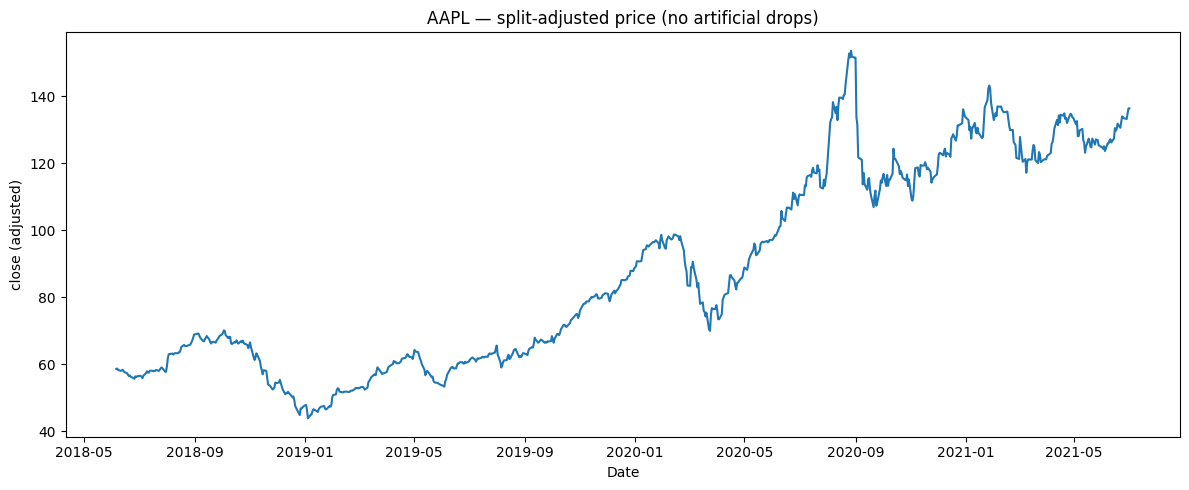

In [51]:
# Split-adjusted time series plot (removes artificial drops like 2020-09)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1) Load CSV ---
path = "AAPL_daily_processed_nosplits.csv"  # cambia la ruta si es necesario
df = pd.read_csv(path)

# --- 2) Detect columns ---
# fecha
date_col = next(
    (c for c in df.columns if c.lower() in ("date", "timestamp", "time", "datetime")),
    next((c for c in df.columns if "date" in c.lower() or "time" in c.lower()), None)
)
assert date_col, f"No date-like column found in: {list(df.columns)}"
df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

# precio (preferimos adjusted/close)
priority = ["adj_close", "adjusted_close", "close", "price", "value"]
lower = {c.lower(): c for c in df.columns}
value_col = next((lower[k] for k in priority if k in lower), None)
if value_col is None:
    candidates = [c for c in df.select_dtypes("number").columns
                  if c.lower() not in {"open","high","low","volume","vol","count","n"}]
    assert candidates, "No numeric column to plot."
    value_col = candidates[0]

df = df.dropna(subset=[date_col, value_col]).sort_values(date_col).reset_index(drop=True)

dates = df[date_col].to_numpy()
y = df[value_col].astype(float).to_numpy()

# --- 3) Back-adjust to remove stock splits ---
# Detect multiplicative jumps (outside the band) and back-adjust so the series sea continua
TH_DOWN, TH_UP = 0.7, 1.5   # puedes afinar estos umbrales si quieres ser más/menos estricto

adj = np.empty_like(y, dtype=float)
scale = 1.0
adj[-1] = y[-1] * scale

for i in range(len(y) - 1, 0, -1):
    r = y[i] / y[i-1]
    if (r < TH_DOWN) or (r > TH_UP):
        # actualizar factor para eliminar el salto por split (o reverse split)
        scale *= r
    adj[i-1] = y[i-1] * scale

# --- 4) Plot ---
plt.figure(figsize=(12,5))
plt.plot(dates, adj)
plt.title("AAPL — split-adjusted price (no artificial drops)")
plt.xlabel("Date")
plt.ylabel(f"{value_col} (adjusted)")
plt.tight_layout()
plt.show()


In [55]:
adj

array([ 58.55549   ,  58.68726044,  58.25087922,  58.01778858,
        58.09949492,  58.30246041,  57.97379285,  57.6181427 ,
        57.30865554,  56.74895626,  56.45409822,  56.60548252,
        56.23964616,  55.83794137,  55.61026892,  56.34291691,
        56.12131284,  56.37065806,  56.4742539 ,  56.51478198,
        55.84465993,  56.56257043,  57.34755816,  57.85448425,
        57.47336859,  57.44790309,  58.02212313,  58.0527901 ,
        57.88395922,  57.90931636,  57.99405689,  58.26745889,
        57.98051141,  58.31643935,  58.6133563 ,  59.02145456,
        58.78435445,  57.76519244,  57.68088537,  59.3441621 ,
        61.71299586,  62.95376194,  63.12909465,  63.1595449 ,
        62.85146647,  63.1325623 ,  63.28470514,  63.23756687,
        63.50728449,  63.50587576,  64.14220996,  65.17847179,
        65.72050776,  65.45003159,  65.37981182,  65.40646933,
        65.52241865,  65.86463168,  66.39886546,  67.0144805 ,
        67.80445296,  68.81321204,  69.09940097,  69.09

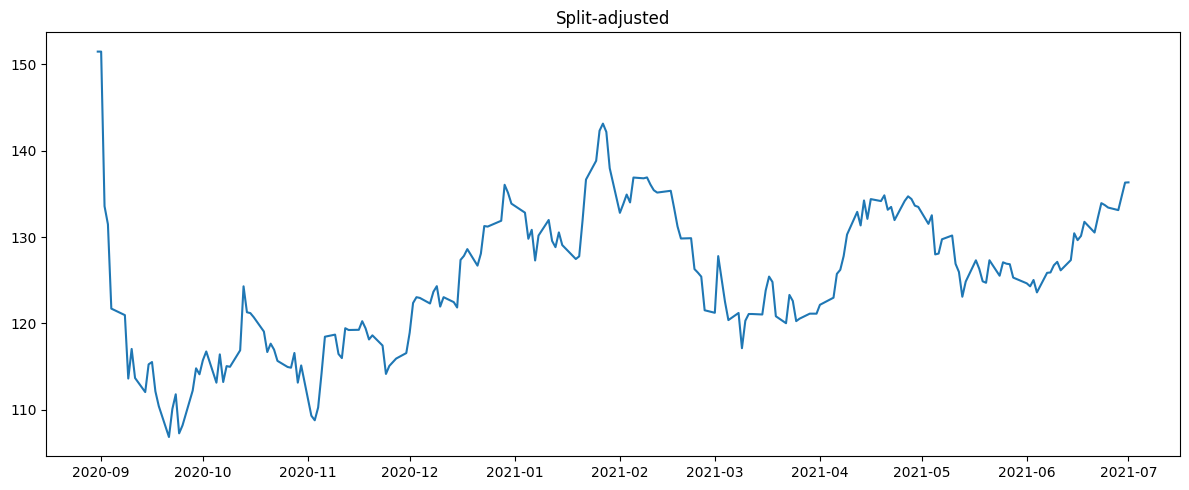

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carga
df = pd.read_csv("AAPL_daily_processed_nosplits.csv")
df=df[df["date"] >= "2020-08-31"]

# Columnas
date_col = next(
    (c for c in df.columns if c.lower() in ("date","timestamp","time","datetime")),
    next((c for c in df.columns if "date" in c.lower() or "time" in c.lower()), None)
)
df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

priority = ["adj_close","adjusted_close","close","price","value"]
lower = {c.lower(): c for c in df.columns}
value_col = next((lower[k] for k in priority if k in lower), None)
if value_col is None:
    candidates = [c for c in df.select_dtypes("number").columns
                  if c.lower() not in {"open","high","low","volume","vol","count","n"}]
    value_col = candidates[0]

df = df.dropna(subset=[date_col, value_col]).sort_values(date_col).reset_index(drop=True)

# Back-adjust (quitar splits)
y = df[value_col].astype(float).to_numpy()
TH_DOWN, TH_UP = 0.7, 1.5
adj = np.empty_like(y, dtype=float)
scale = 1.0
adj[-1] = y[-1] * scale
for i in range(len(y)-1, 0, -1):
    r = y[i] / y[i-1]
    if (r < TH_DOWN) or (r > TH_UP):
        scale *= r
    adj[i-1] = y[i-1] * scale

# Añadir al DataFrame
df["adj"] = adj

# (Opcional) Guardar
# df.to_csv("AAPL_daily_processed_nosplits_with_adj.csv", index=False)

# (Opcional) Grafico
plt.figure(figsize=(12,5))
plt.plot(df[date_col], df["adj"])
plt.title("Split-adjusted")
plt.tight_layout()
plt.show()


In [63]:
df[df["date"] >= "2020-08-31"]

,date,open,high,low,last,close,volume,adj
563,2020-08-31,3758.400000,3901.952500,3752.100000,3879.855000,14976.900000,4.690758e+04,151.475758
564,2020-09-01,131.771212,133.354394,130.233636,132.622424,151.475758,9.157638e+05,151.475758
565,2020-09-02,137.005476,137.554286,128.342738,131.138095,133.568095,1.352268e+06,133.568095
566,2020-09-03,128.315325,128.971948,122.190649,123.678896,131.472208,4.090409e+06,131.472208
567,2020-09-04,119.019211,124.051447,112.657829,118.658684,121.710526,2.272773e+06,121.710526
...,...,...,...,...,...,...,...,...
769,2021-06-25,133.416050,133.691885,133.222298,133.309618,133.413694,4.656618e+05,133.413694
770,2021-06-28,133.303353,134.421098,133.289840,134.858172,133.118157,6.426435e+05,133.118157
771,2021-06-29,134.761342,135.700085,134.664658,135.993108,134.733754,9.761032e+05,134.733754
772,2021-06-30,136.250912,136.804105,136.086106,136.798682,136.306515,6.235195e+05,136.306515
